In [1]:
import numpy as np
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, MaxPooling2D, Conv2D

# Load data
(train_x, train_y), (test_x, test_y) = fashion_mnist.load_data()

# Normalize
train_x = train_x / 255.0
test_x = test_x / 255.0

# Reshape for CNN
train_x = train_x.reshape(-1, 28, 28, 1)
test_x = test_x.reshape(-1, 28, 28, 1)

# Model
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(train_x, train_y, epochs=5, validation_split=0.2)

# Evaluate
loss, acc = model.evaluate(test_x, test_y)
print("Accuracy:", acc)

C:\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 17ms/step - accuracy: 0.8594 - loss: 0.3947 - val_accuracy: 0.8938 - val_loss: 0.2969
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9020 - loss: 0.2695 - val_accuracy: 0.8957 - val_loss: 0.2803
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.9190 - loss: 0.2213 - val_accuracy: 0.9042 - val_loss: 0.2594
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.9314 - loss: 0.1856 - val_accuracy: 0.9068 - val_loss: 0.2562
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9429 - loss: 0.1554 - val_accuracy: 0.9184 - val_loss: 0.2447
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9128 - loss: 0.2599
Accuracy: 0.9128000140190125


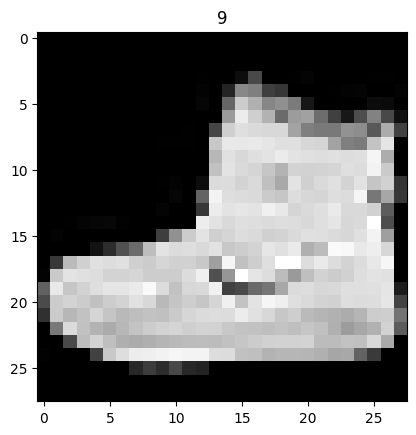

In [2]:
import matplotlib.pyplot as plt

plt.imshow(train_x[0], cmap='gray')
plt.title(train_y[0])
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


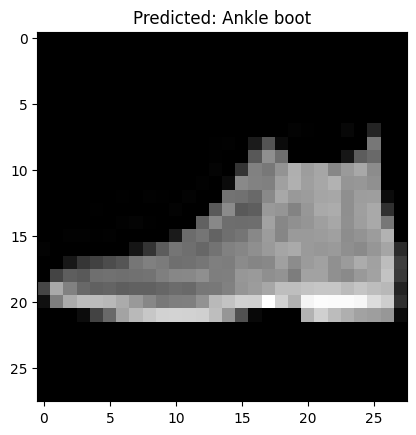

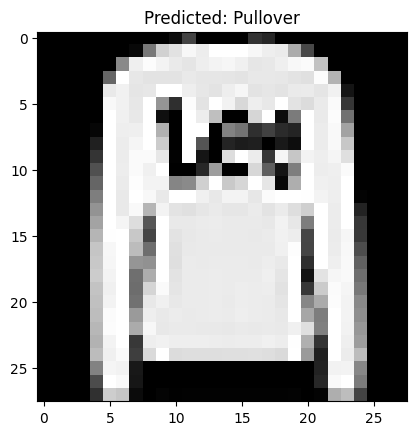

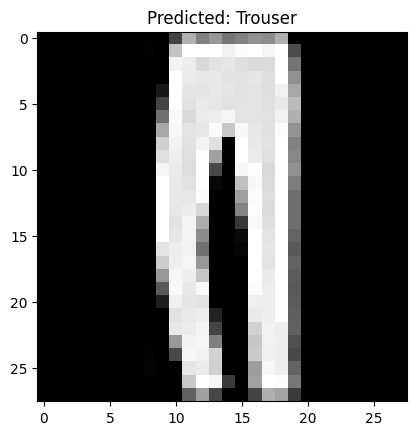

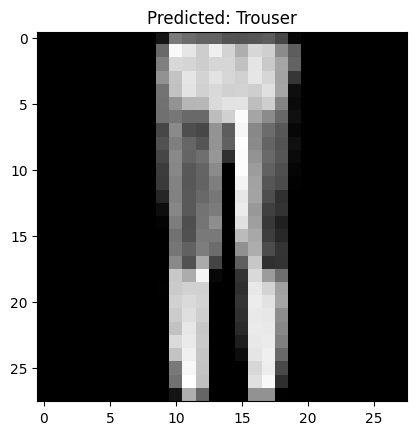

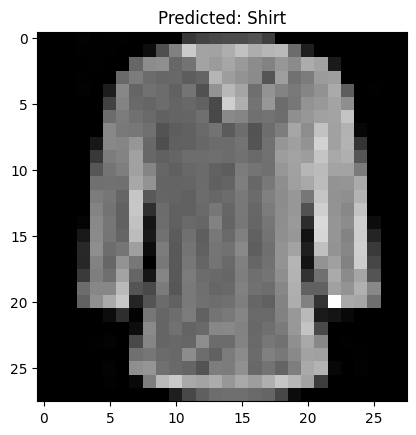

In [5]:
import numpy as np
import matplotlib.pyplot as plt

labels = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
          'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

predictions = model.predict(test_x)

for i in range(5):
    plt.imshow(test_x[i].reshape(28,28), cmap='gray')
    plt.title(f"Predicted: {labels[np.argmax(predictions[i])]}")
    plt.show()